# Square and rectangular published J-Lenses

Read completed comparison artifacts; this notebook never loads a model or scores captures.
Direct comparisons use layers **19–39**. The square-only view retains **0–41**.
Cohorts use the original model's saved correctness labels. Each cell has one observation
per example; ranks use strict `>` and argmax ties select the lowest token ID.
A tied rank-one target can differ from the winning token.

All differences are **square minus rectangular**. Positive differences indicate greater
target readability for top-1 rates, MRR and log-probability. Absolute panels share a scale;
differences use a scale centered on zero. Log-probabilities use the complete vocabulary.

The artifacts' fitting recipes and model/backend provenance differ. Differences cannot be
attributed solely to averaging versus flattening; these readouts do not measure causal effects.

New comparisons include separate **Answer**, **:** and **space** positions at every supported layer. Available filler lengths and positions come from the selected result. Historical runs without Answer/colon are explicitly labeled.


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'filler').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open the notebook within the project workspace')
sys.path.insert(0, str(ROOT))
from filler.dsv4.jlens_comparison import load_completed, plot_comparison, inspect_example, METRICS

# Select a completed allocation directory here. Export execution replaces RUN explicitly.
completed_runs = sorted((ROOT / 'runs/deepseek-v4-flash/jlens-comparison').glob('*/COMPLETE.json'),
                        key=lambda p: p.stat().st_mtime)
completed_runs = [p for p in completed_runs if not (p.parent / 'FAILED.json').exists()]
DEFAULT_RUN = completed_runs[-1].parent if completed_runs else ROOT / 'runs/deepseek-v4-flash/jlens-comparison/COMPLETE_RUN'
RUN = DEFAULT_RUN
summary, square_summary = load_completed(RUN)
paired_summary = pd.DataFrame(summary)
filler_lengths = sorted(paired_summary.filler_length.unique().tolist())
default_length = 20 if 20 in filler_lengths else filler_lengths[-1]
from filler.dsv4.top_object_heatmap import position_order
def available_positions(k):
    return sorted(paired_summary[paired_summary.filler_length == k].position_label.unique(), key=lambda p: position_order(p, k))
coverage = {k: all(p in available_positions(k) for p in ('answer_word', 'answer_colon', 'answer_prompt')) for k in filler_lengths}
print('Answer/colon/space coverage:', coverage)
if not all(coverage.values()):
    print('HISTORICAL COVERAGE: Answer and colon are absent for the lengths marked False.')
print(f'Results: {RUN}')
display(pd.read_csv(RUN / f'overview_k{default_length}_all.csv'))


Answer/colon/space coverage: {0: True, 20: True}
Results: /pscratch/sd/m/marocco/sandbox/mech_int/runs/deepseek-v4-flash/jlens-comparison/58185137


,target,pairs,square_top1,rectangular_top1,difference_top1,square_mrr,rectangular_mrr,difference_mrr,square_logprob,rectangular_logprob,difference_logprob,full_agreement
0,A,48384,0.017320,0.010396,0.006924,0.025924,0.013993,0.011931,-17.082885,-34.406766,17.323881,0.07767
1,X,48384,0.025318,0.004113,0.021205,0.041395,0.006801,0.034595,-15.890144,-33.133235,17.243091,0.07767
2,A+X,48384,0.008867,0.010251,-0.001385,0.013830,0.012691,0.001139,-18.467988,-34.559029,16.091041,0.07767


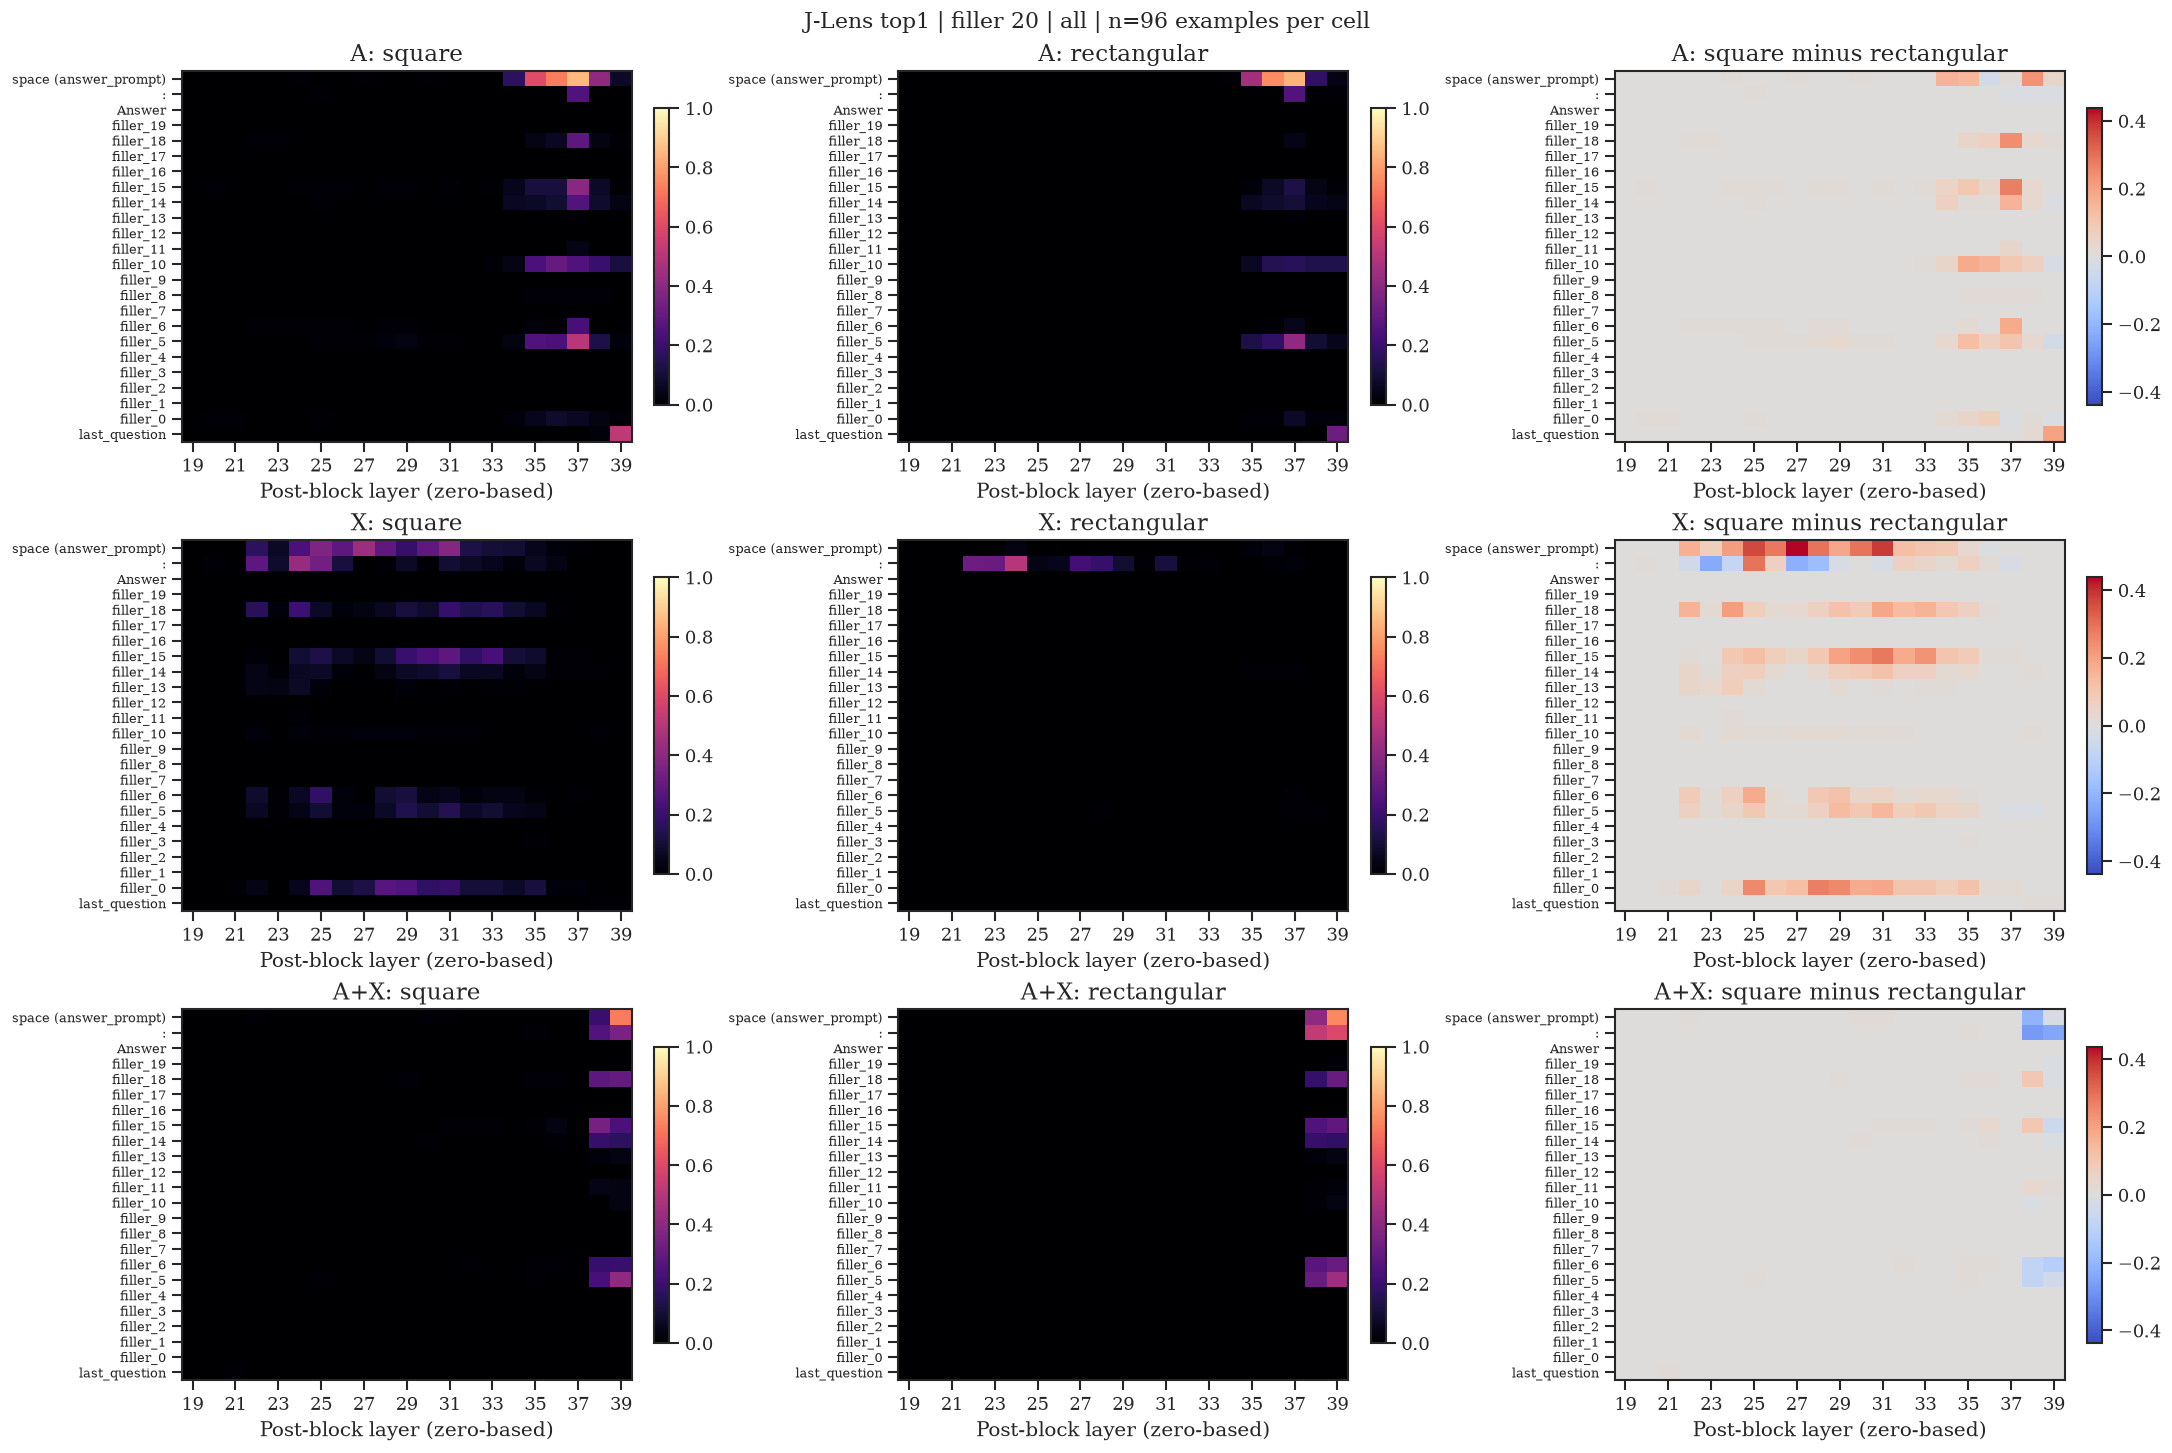

,target_name,position_label,layer,n,full_agreement,full_square_only,full_rectangular_only,numeric_agreement,numeric_square_only,numeric_rectangular_only
0,A,answer_colon,19,96,0.000000,0,0,0.197917,0,0
1,A+X,answer_colon,19,96,0.000000,0,0,0.197917,0,0
2,X,answer_colon,19,96,0.000000,0,0,0.197917,0,0
3,A,answer_colon,20,96,0.000000,0,0,0.208333,0,0
4,A+X,answer_colon,20,96,0.000000,0,0,0.208333,0,0
...,...,...,...,...,...,...,...,...,...,...
1507,A+X,last_question,38,96,0.020833,0,0,0.375000,1,0
1508,X,last_question,38,96,0.020833,1,0,0.375000,2,0
1509,A,last_question,39,96,0.343750,22,3,0.843750,6,1
1510,A+X,last_question,39,96,0.343750,0,0,0.843750,0,0


In [2]:
def show_comparison(filler_length=default_length, cohort='all', metric='top1', view='paired'):
    stats = square_summary if view == 'square: all layers' else summary
    fig = plot_comparison(stats, filler_length, cohort, metric,
                          square_only=(view == 'square: all layers'))
    display(fig)
    plt.close(fig)
    selected = paired_summary[(paired_summary.filler_length == filler_length)
                              & (paired_summary.cohort == cohort)]
    columns = ['target_name', 'position_label', 'layer', 'n',
               'full_agreement', 'full_square_only', 'full_rectangular_only',
               'numeric_agreement', 'numeric_square_only', 'numeric_rectangular_only']
    # The entire agreement/count table remains scrollable in the notebook and in summary.csv.
    display(selected[columns].reset_index(drop=True))

# Static default output is retained in the executed notebook even without widget support.
show_comparison()


In [3]:
import ipywidgets as widgets

length_selector = widgets.Dropdown(options=filler_lengths, value=default_length, description='Filler')
cohort_selector = widgets.Dropdown(options=['all', 'correct', 'wrong'], value='all', description='Cohort')
metric_selector = widgets.Dropdown(options=[('Full-vocabulary top-1', 'top1'),
    ('Numeric-only top-1', 'numeric_top1'), ('Mean reciprocal rank', 'mrr'),
    ('Mean full-vocabulary log-probability', 'logprob')], value='top1', description='Metric')
view_selector = widgets.Dropdown(options=['paired', 'square: all layers'], value='paired', description='View')
comparison_output = widgets.Output()
def redraw(_=None):
    with comparison_output:
        comparison_output.clear_output(wait=True)
        show_comparison(length_selector.value, cohort_selector.value, metric_selector.value, view_selector.value)
for control in (length_selector, cohort_selector, metric_selector, view_selector):
    control.observe(redraw, names='value')
display(widgets.VBox([widgets.HBox([length_selector, cohort_selector]),
                     widgets.HBox([metric_selector, view_selector]), comparison_output]))


## Per-example inspection

Winning token text preserves whitespace. Exact target ranks and full-vocabulary log-probabilities
are stored for both lenses, along with token IDs and capture hashes. The table shows all three
targets at the selected position/layer. Full example trajectories can also be read with
`inspect_example(RUN, filler_length, cell_id)` or from `paired.csv` / `paired.json`.


In [4]:
example_catalog = pd.read_csv(RUN / 'paired.csv', usecols=['filler_length', 'cell_id']).drop_duplicates()
example_length = widgets.Dropdown(options=filler_lengths, value=default_length, description='Filler')
example_id = widgets.Dropdown(options=sorted(example_catalog[example_catalog.filler_length == default_length].cell_id), description='Example', layout=widgets.Layout(width='90%'))
example_position = widgets.Dropdown(options=available_positions(default_length), value='answer_prompt', description='Position')
example_layer = widgets.IntSlider(min=19, max=39, value=39, description='Layer')
example_output = widgets.Output()
def show_example(_=None):
    with example_output:
        example_output.clear_output(wait=True)
        table = inspect_example(RUN, example_length.value, example_id.value, example_position.value, example_layer.value)
        columns = ['target_name', 'target_token_text', 'clean_correct',
                   'square_top_token_text', 'rectangular_top_token_text',
                   'square_top_numeric_token_text', 'rectangular_top_numeric_token_text',
                   'square_rank', 'rectangular_rank', 'square_logprob', 'rectangular_logprob']
        if not table.empty:
            display(table[columns])
def change_example_length(_):
    example_id.options = sorted(example_catalog[example_catalog.filler_length == example_length.value].cell_id)
    example_position.options = available_positions(example_length.value)
    show_example()
example_length.observe(change_example_length, names='value')
for control in (example_id, example_position, example_layer):
    control.observe(show_example, names='value')
display(widgets.VBox([example_length, example_id, widgets.HBox([example_position, example_layer]), example_output]))
# Static inspection also survives export to notebook viewers without live widgets.
initial_example = inspect_example(RUN, default_length, example_id.value, 'answer_prompt', 39)
display(initial_example)


,filler_length,cell_id,position_label,layer,panel_id,split,row,col,left_value,right_value,...,full_square_only,full_rectangular_only,numeric_agreement,numeric_square_only,numeric_rectangular_only,square_top_token_text,rectangular_top_token_text,square_top_numeric_token_text,rectangular_top_numeric_token_text,target_token_text
0,20,discovery-filler-0743614aafcd1ceb0a07:00,answer_prompt,39,discovery-filler-0743614aafcd1ceb0a07,discovery,0,0,19,24,...,0,0,1,0,0,43,43,43,43,19
1,20,discovery-filler-0743614aafcd1ceb0a07:00,answer_prompt,39,discovery-filler-0743614aafcd1ceb0a07,discovery,0,0,19,24,...,0,0,1,0,0,43,43,43,43,24
2,20,discovery-filler-0743614aafcd1ceb0a07:00,answer_prompt,39,discovery-filler-0743614aafcd1ceb0a07,discovery,0,0,19,24,...,0,0,1,0,0,43,43,43,43,43


## Exports and validation

`comparison_k{length}_{cohort}_{metric}.png` / `.pdf` contain all paired panels.
`square_k{length}_{cohort}_{metric}.png` / `.pdf` show all square layers.
`summary.csv` / `.json` include agreement rates and both exclusive-selection counts.
`paired.csv` / `.json` retain exact per-example metrics and decoded winners.
`REPORT.md` records interpretation and limitations; `validation.json`, `pilot_checks.json`,
`baseline_validation.json`, `provenance.json` and `capture_sha256.json` preserve validation and inputs.
